In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx

# Boids

In [ ]:
def get_adjacency(p):
    A = np.zeros((N, N))
    for j in range(N):
        for i in range(j):
            r = np.linalg.norm(p[i] - p[j])
            if r <= R:
                A[i, j] = 1
    A += A.T
    return A

def get_u_sep(p, v, A):
    u_sep = np.zeros((N, 2))
    for i in range(N):
        tmp = np.zeros((N, 2))
        for j in range(N):
            if i == j or A[i, j] == 0:
                continue
            r = p[i] - p[j]
            rmag = np.linalg.norm(r)
            if rmag > 1e-8:
                tmp[j] = max(0, r0 - rmag)*r/rmag
        u_sep[i] = k_sep*np.sum(tmp, axis=0)
    return u_sep

def get_u_ali(p, v, A, d):
    u_ali = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            vbar = np.sum(A[i, :, None] * v, axis=0) / d[i]
            u_ali[i] = k_ali * (vbar - v[i])
    return u_ali

def get_u_coh(p, v, A, d):
    u_coh = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            pbar = np.sum(A[i, :, None] * p, axis=0) / d[i]
            u_coh[i] = k_coh * (pbar - p[i])
    return u_coh

def f(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency(p)
    d = A @ np.ones(N)

    u_sep = get_u_sep(p, v, A)
    u_ali = get_u_ali(p, v, A, d)
    u_coh = get_u_coh(p, v, A, d)

    pdot = v
    vdot = u_sep + u_ali + u_coh

    return np.concatenate((pdot, vdot)).flatten()


def plot_boid_trajectories(sol, N):

    p_traj = sol.y[:2*N, :]


    plt.figure(figsize=(6, 6))
    for i in range(N):
        plt.plot(p_traj[2*i], p_traj[2*i+1], lw=1.2, alpha=0.8)
    
    plt.title("Boid Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid()
    plt.show()

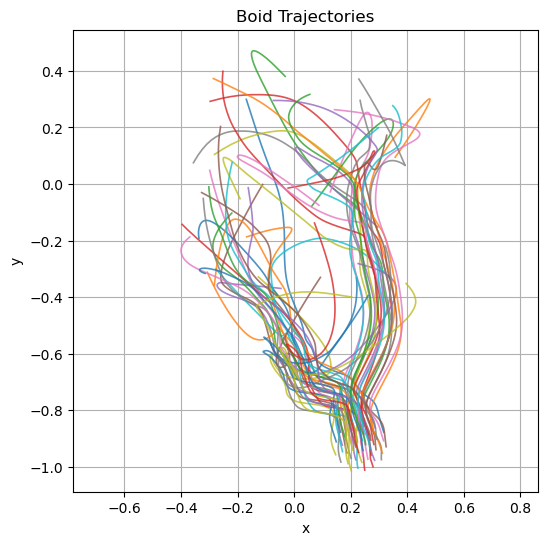

In [256]:
N = 50
x = 0.4 * np.random.uniform(-1,1,(2*N,2))
R = 0.3
k_sep = 2
k_ali = 1
k_coh = 1
r0 = 0.05

# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
sol = solve_ivp(f, tspan, x.flatten(), t_eval=t_eval)

plot_boid_trajectories(sol,N)

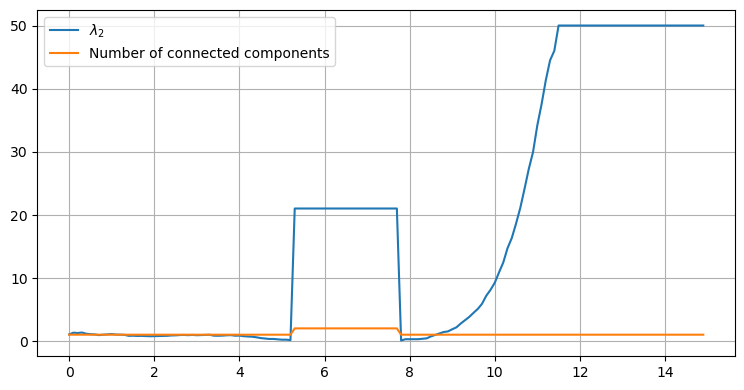

In [257]:
def get_D_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) 
    L = D-A
    return D,L

def get_lambda_2(sol):
    lambda_2_ary = np.zeros(len(t_eval))
    components_ary = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        p = sol.y[:2*N, i].reshape(N, 2)
        A = get_adjacency(p)
        D,L = get_D_L(A)
        vals = np.real(np.linalg.eigvals(L))
        vals_sorted = np.sort(vals)
        G = nx.Graph(A)
        nc=nx.number_connected_components(G)
        components_ary[i] = nc
        lambda_2 = vals_sorted[nc]
        #print(lambda_2)
        lambda_2_ary[i]=lambda_2
    return lambda_2_ary, components_ary

l2,ca = get_lambda_2(sol)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

[0.28043316 0.28031376 0.27890745 0.97972857 0.81203727 0.68743937
 0.61260784 0.20117992 0.20371422 0.18185938 0.18159235 1.58578644
 1.58578644 1.58578644 1.58578644 1.58578644 1.58578644 1.58578644
 1.90258232 1.98694155 2.         2.10440798 2.21875574 2.82897021
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3.         3.         3.         3.
 3.         3.         3

In [222]:
vals_sorted[-1]

12.000000000000012

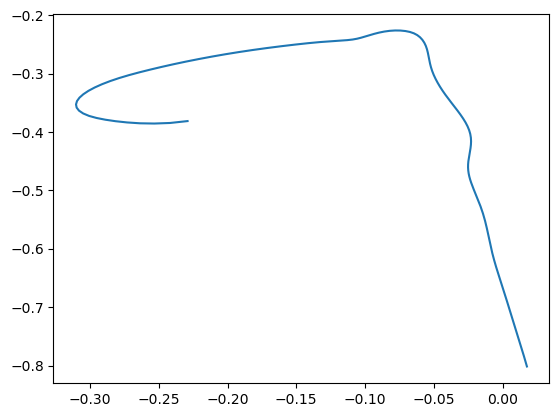

In [171]:
plt.plot(p_traj[0],p_traj[1])

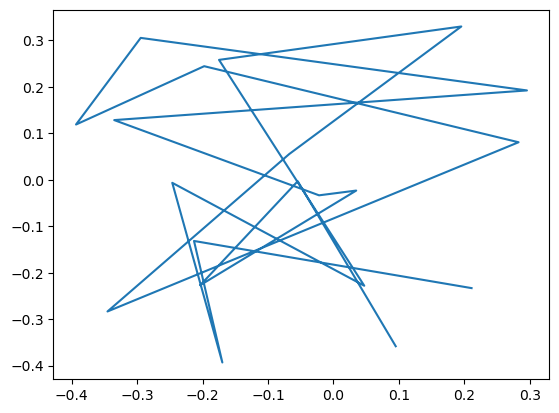

In [178]:
plt.plot(p_k.T[0],p_k.T[1])

In [177]:
p_k.T

array([[ 0.09517252, -0.05454819, -0.20352011,  0.03484036, -0.02195295,
        -0.33491088,  0.29560727, -0.29443086, -0.3932259 , -0.19740564,
         0.28283163, -0.34513032, -0.06759865,  0.19538082, -0.17474042,
         0.0471396 , -0.2461868 , -0.16968252, -0.21296969,  0.21102258],
       [-0.35826213, -0.00318648, -0.22695497, -0.02328877, -0.03352582,
         0.12835281,  0.19216922,  0.30523519,  0.1188115 ,  0.24432504,
         0.08069214, -0.28342946,  0.05518744,  0.3297861 ,  0.25791713,
        -0.22808889, -0.0066175 , -0.39319669, -0.13173531, -0.23317784]])

3